In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
df_pos = pd.read_csv('/content/drive/MyDrive/Thesis/Pos Dataset.csv')
df_pos

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C145,C146,C147,C148,C149,C150,C151,C152,C153,class
0,35141,1047051,41527343,1856306445,1046158,31159371,1233964119,41110980,1225020277,1814866984,...,243810,114721,346611,374615,394713,453238,141629,138537,0,1
1,2685,22196,240762,2951180,22101,179386,1923320,235939,1876790,2841159,...,1579,2152,1300,2485,1754,2270,1111,677,0,1
2,824,4154,26092,183302,4206,21176,132266,26432,131618,183630,...,135,2,370,319,88,30,40,0,0,1
3,8842,136558,2762124,62896558,130662,2012908,40731716,2534428,38933692,55378950,...,22487,19351,13697,32217,19893,20120,3062,12924,0,1
4,7504,107289,1967601,40342947,107090,1531399,28020981,1978172,28239377,40913240,...,24298,11033,10797,26283,10130,14104,3009,3225,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3992,6492,87389,1536921,30454451,83938,1116033,19400871,1417372,18625591,26867074,...,5113,11797,10595,18379,12169,6839,1091,4748,0,1
3993,4722,53411,795737,13359665,48955,548913,8195235,662033,7343421,10108807,...,4655,5791,1733,8018,6517,5932,1067,5026,0,1
3994,2238,19136,212112,2638694,17070,143295,1571849,169830,1404347,1907250,...,824,1237,576,1360,1377,1795,507,1172,0,1
3995,2717,23785,273447,3551767,21986,188048,2130904,230326,1926166,2728436,...,594,1264,1061,3666,2102,3766,434,1461,0,1


In [ ]:
df_neg = pd.read_csv('/content/drive/MyDrive/Thesis/Neg Dataset.csv')
df_neg

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C145,C146,C147,C148,C149,C150,C151,C152,C153,class
0,531,2467,14033,88213,2045,9452,53370,9905,44820,54095,...,28,137,103,7,90,109,0,55,0,0
1,195,531,1685,5811,475,1284,4082,1421,3788,4765,...,5,13,20,0,0,0,14,15,0,0
2,693,3402,21462,152736,3026,14658,91996,16356,77072,98978,...,447,65,187,183,131,0,35,33,0,0
3,1186,7076,53318,450110,6450,37749,281991,43748,251579,329814,...,607,267,43,704,419,595,93,99,0,0
4,1892,13982,134666,1468904,13294,98340,948360,118710,875948,1192252,...,664,289,478,1652,1388,1140,130,292,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7348,566,2541,14347,90861,1994,8915,50871,8764,38627,43568,...,81,0,0,84,113,17,47,91,0,0
7349,718,3219,18453,118773,2864,12298,68826,14594,59892,84698,...,103,0,66,115,363,47,0,93,0,0
7350,1237,7014,49602,391356,6536,36808,258562,43412,239936,324218,...,82,0,55,262,307,28,187,827,0,0
7351,638,2759,15015,92063,2499,10456,55706,12047,48916,65031,...,103,0,112,14,242,69,0,106,0,0


In [ ]:
import pandas as pd

# assuming your tw//////////////o dataframes are called "df1" and "df2"
df = pd.concat([df_pos, df_neg], ignore_index=True)
#random_records = df_neg.sample(n=6000, random_state=42)
#df = pd.concat([random_records, df_pos], ignore_index=True)

In [ ]:
df.shape

(11350, 154)

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
import numpy as np

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, matthews_corrcoef
import matplotlib.pyplot as plt
import lightgbm as lgb

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import MinMaxScaler

X = df.drop(['class'], axis=1).values
y = df['class'].values



std_scale = MinMaxScaler().fit(X)
X = std_scale.fit_transform(X)
X = np.nan_to_num(X.astype('float32'))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


**LSTM** model

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping

# Define the number of folds for cross-validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store evaluation metrics
f1_scores = []
mcc_scores = []
sensitivity_scores = []
specificity_scores = []
roc_auc_scores = []
accuracy_scores = []  # Add accuracy_scores list

# Perform 5-fold cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Reshape the data into the required format for LSTM
    timesteps = 1
    features = 153
    X_train = X_train.reshape(X_train.shape[0], timesteps, features)
    X_test = X_test.reshape(X_test.shape[0], timesteps, features)

    # Define the LSTM model architecture with multiple hidden layers
    model = Sequential()
    model.add(LSTM(128, input_shape=(timesteps, features), return_sequences=True))  # First LSTM layer with return_sequences=True
    model.add(LSTM(64, return_sequences=True))  # Second LSTM layer with return_sequences=True
    model.add(LSTM(32, return_sequences=True))  # Third LSTM layer with return_sequences=True
    model.add(LSTM(16, return_sequences=True))  # Fourth LSTM layer with return_sequences=True
    model.add(LSTM(8))  # Fifth LSTM layer without return_sequences=True
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Define early stopping callback
    # early_stop = EarlyStopping(monitor='val_loss', patience=30, verbose=1)
    # Define early stopping callback based on validation accuracy
    early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=30, mode='max', verbose=1, restore_best_weights=True)


    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=True)

    # Evaluate the model on the testing data
    y_pred = model.predict(X_test)
    y_pred_class = np.round(y_pred)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred_class)

    # Calculate additional evaluation metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_class).ravel()
    mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # Calculate ROC curve and AUC
    lstm_fpr, lstm_tpr, thresholds = roc_curve(y_test, y_pred)
    lstm_roc_auc = auc(lstm_fpr, lstm_tpr)

    # Append scores to lists
    f1_scores.append(f1)
    mcc_scores.append(mcc)
    sensitivity_scores.append(sensitivity)
    specificity_scores.append(specificity)
    roc_auc_scores.append(lstm_roc_auc)
    accuracy_scores.append(test_acc)  # Add accuracy score

# Calculate average scores across folds
avg_f1_score = np.mean(f1_scores)
avg_mcc_score = np.mean(mcc_scores)
avg_sensitivity_score = np.mean(sensitivity_scores)
avg_specificity_score = np.mean(specificity_scores)
avg_roc_auc_score = np.mean(roc_auc_scores)
avg_accuracy_score = np.mean(accuracy_scores)  # Calculate average accuracy score

# Print average scores
print("Average F1 Score across folds:", avg_f1_score)
print("Average MCC across folds:", avg_mcc_score)
print("Average Sensitivity across folds:", avg_sensitivity_score)
print("Average Specificity across folds:", avg_specificity_score)
print("Average ROC AUC across folds:", avg_roc_auc_score)
print("Average Accuracy across folds:", avg_accuracy_score)  # Print average accuracy score


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6550 - loss: 0.6553 - val_accuracy: 0.9013 - val_loss: 0.4046
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9216 - loss: 0.3429 - val_accuracy: 0.9498 - val_loss: 0.2371
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9411 - loss: 0.2308 - val_accuracy: 0.9374 - val_loss: 0.2006
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9401 - loss: 0.1972 - val_accuracy: 0.9515 - val_loss: 0.1667
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9386 - loss: 0.1915 - val_accuracy: 0.9507 - val_loss: 0.1626
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9503 - loss: 0.1645 - val_accuracy: 0.9181 - val_loss: 0.2216
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9457 - loss: 0.1749 - val_accuracy: 0.9533 - val_loss: 0.1557
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9451 - loss: 0.1694 - val_acc

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6659 - loss: 0.6589 - val_accuracy: 0.8996 - val_loss: 0.4185
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9127 - loss: 0.3646 - val_accuracy: 0.9427 - val_loss: 0.2462
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9199 - loss: 0.2660 - val_accuracy: 0.9110 - val_loss: 0.2736
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9369 - loss: 0.2007 - val_accuracy: 0.9357 - val_loss: 0.1938
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9373 - loss: 0.1939 - val_accuracy: 0.9419 - val_loss: 0.1789
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9433 - loss: 0.1738 - val_accuracy: 0.9507 - val_loss: 0.1624
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9385 - loss: 0.1821 - val_accuracy: 0.9436 - val_loss: 0.1805
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9472 - loss: 0.1687 - val_accuracy: 0.95

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6544 - loss: 0.6585 - val_accuracy: 0.8899 - val_loss: 0.4386
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9261 - loss: 0.3360 - val_accuracy: 0.9401 - val_loss: 0.2464
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9406 - loss: 0.2252 - val_accuracy: 0.9207 - val_loss: 0.2382
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9403 - loss: 0.1974 - val_accuracy: 0.9374 - val_loss: 0.1978
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9439 - loss: 0.1836 - val_accuracy: 0.9436 - val_loss: 0.1742
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9436 - loss: 0.1801 - val_accuracy: 0.9427 - val_loss: 0.1735
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9445 - loss: 0.1765 - val_accuracy: 0.9454 - val_loss: 0.1700
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9449 - loss: 0.1732 - val_accuracy: 0.94

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.6688 - loss: 0.6461 - val_accuracy: 0.9181 - val_loss: 0.3580
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9205 - loss: 0.3303 - val_accuracy: 0.9577 - val_loss: 0.2026
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9305 - loss: 0.2456 - val_accuracy: 0.9374 - val_loss: 0.1969
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9378 - loss: 0.1961 - val_accuracy: 0.9410 - val_loss: 0.1733
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9295 - loss: 0.2191 - val_accuracy: 0.9604 - val_loss: 0.1442
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9448 - loss: 0.1757 - val_accuracy: 0.9401 - val_loss: 0.1878
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9413 - loss: 0.1799 - val_accuracy: 0.9436 - val_loss: 0.1547
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9460 - loss: 0.1700 - val_accuracy: 0.95

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6530 - loss: 0.6515 - val_accuracy: 0.9436 - val_loss: 0.3220
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9287 - loss: 0.3178 - val_accuracy: 0.9066 - val_loss: 0.3047
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9277 - loss: 0.2412 - val_accuracy: 0.9225 - val_loss: 0.2464
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9387 - loss: 0.1979 - val_accuracy: 0.9498 - val_loss: 0.1720
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9498 - loss: 0.1714 - val_accuracy: 0.9286 - val_loss: 0.2193
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9346 - loss: 0.1951 - val_accuracy: 0.9260 - val_loss: 0.2206
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9408 - loss: 0.1852 - val_accuracy: 0.9463 - val_loss: 0.1654
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9524 - loss: 0.1581 - val_acc

In [ ]:
for i, acc in enumerate(accuracy_scores, 1):
    print(f"Fold {i}: Accuracy = {acc}")


Fold 1: Accuracy = 0.9550660848617554
Fold 2: Accuracy = 0.9559471607208252
Fold 3: Accuracy = 0.9550660848617554
Fold 4: Accuracy = 0.9568281769752502
Fold 5: Accuracy = 0.9480175971984863
Fold 6: Accuracy = 0.9533039927482605
Fold 7: Accuracy = 0.9577092528343201
Fold 8: Accuracy = 0.9462555050849915
Fold 9: Accuracy = 0.966519832611084
Fold 10: Accuracy = 0.9577092528343201


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix, roc_curve, auc

# Define the number of folds for cross-validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store evaluation metrics
f1_scores = []
mcc_scores = []
sensitivity_scores = []
specificity_scores = []
roc_auc_scores = []
accuracy_scores = []  # Add accuracy_scores list

# Perform 5-fold cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Reshape the data into the required format for SimpleRNN
    timesteps = 1
    features = 153
    X_train = X_train.reshape(X_train.shape[0], timesteps, features)
    X_test = X_test.reshape(X_test.shape[0], timesteps, features)

    # Define the SimpleRNN model architecture with multiple hidden layers
    model = Sequential()
    model.add(SimpleRNN(128, input_shape=(timesteps, features), return_sequences=True))  # First SimpleRNN layer with return_sequences=True
    model.add(SimpleRNN(64, return_sequences=True))  # Second SimpleRNN layer with return_sequences=True
    model.add(SimpleRNN(32, return_sequences=True))  # Third SimpleRNN layer with return_sequences=True
    model.add(SimpleRNN(16, return_sequences=True))  # Fourth SimpleRNN layer with return_sequences=True
    model.add(SimpleRNN(8))  # Fifth SimpleRNN layer without return_sequences=True
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Define early stopping callback
    # early_stop = EarlyStopping(monitor='val_loss', patience=30, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=30, mode='max', verbose=1, restore_best_weights=True)

    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=True)

    # Evaluate the model on the testing data
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Predict labels for the test data
    y_pred = model.predict(X_test)
    y_pred_binary = np.round(y_pred)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred_binary)

    # Calculate additional evaluation metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    mcc = matthews_corrcoef(y_test, y_pred_binary)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # Calculate ROC curve and AUC
    rnn_fpr, rnn_tpr, thresholds = roc_curve(y_test, y_pred)
    rnn_roc_auc = auc(rnn_fpr, rnn_tpr)

    # Append scores to lists
    f1_scores.append(f1)
    mcc_scores.append(mcc)
    sensitivity_scores.append(sensitivity)
    specificity_scores.append(specificity)
    roc_auc_scores.append(rnn_roc_auc)
    accuracy_scores.append(test_acc)  # Add accuracy score

# Calculate average scores across folds
avg_f1_score = np.mean(f1_scores)
avg_mcc_score = np.mean(mcc_scores)
avg_sensitivity_score = np.mean(sensitivity_scores)
avg_specificity_score = np.mean(specificity_scores)
avg_roc_auc_score = np.mean(roc_auc_scores)
avg_accuracy_score = np.mean(accuracy_scores)  # Calculate average accuracy score

# Print average scores
print("Average F1 Score across folds:", avg_f1_score)
print("Average MCC across folds:", avg_mcc_score)
print("Average Sensitivity across folds:", avg_sensitivity_score)
print("Average Specificity across folds:", avg_specificity_score)
print("Average ROC AUC across folds:", avg_roc_auc_score)
print("Average Accuracy across folds:", avg_accuracy_score)  # Print average accuracy score


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8033 - loss: 0.4543 - val_accuracy: 0.9454 - val_loss: 0.1890
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9283 - loss: 0.2187 - val_accuracy: 0.9498 - val_loss: 0.1744
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9316 - loss: 0.2019 - val_accuracy: 0.9383 - val_loss: 0.1823
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9456 - loss: 0.1716 - val_accuracy: 0.9084 - val_loss: 0.2579
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9344 - loss: 0.1945 - val_accuracy: 0.8705 - val_loss: 0.3010
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9345 - loss: 0.1928 - val_accuracy: 0.9445 - val_loss: 0.1702
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9468 - loss: 0.1678 - val_accuracy: 0.9216 - val_loss: 0.2127
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9396 - loss: 0.1819 - val_accuracy: 0.9463 - va

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7816 - loss: 0.4661 - val_accuracy: 0.9198 - val_loss: 0.2235
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9322 - loss: 0.2078 - val_accuracy: 0.9251 - val_loss: 0.2241
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9271 - loss: 0.2139 - val_accuracy: 0.9524 - val_loss: 0.1678
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9386 - loss: 0.1888 - val_accuracy: 0.9330 - val_loss: 0.1941
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9415 - loss: 0.1778 - val_accuracy: 0.9419 - val_loss: 0.1786
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9411 - loss: 0.1799 - val_accuracy: 0.9551 - val_loss: 0.1611
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9443 - loss: 0.1697 - val_accuracy: 0.9348 - val_loss: 0.1825
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9520 - loss: 0.1601 - val_accuracy: 

...

160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7653 - loss: 0.4868 - val_accuracy: 0.9330 - val_loss: 0.1988
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9265 - loss: 0.2163 - val_accuracy: 0.9295 - val_loss: 0.2015
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9375 - loss: 0.1898 - val_accuracy: 0.9110 - val_loss: 0.2619
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9380 - loss: 0.1874 - val_accuracy: 0.9154 - val_loss: 0.2222
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9450 - loss: 0.1773 - val_accuracy: 0.8996 - val_loss: 0.3202
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9301 - loss: 0.2082 - val_accuracy: 0.9339 - val_loss: 0.1791
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9436 - loss: 0.1742 - val_accuracy: 0.9251 - val_loss: 0.1904
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9405 - loss: 0.1795 - val_accuracy: 0.9436 - val

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7848 - loss: 0.4752 - val_accuracy: 0.9145 - val_loss: 0.2464
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9323 - loss: 0.2046 - val_accuracy: 0.9084 - val_loss: 0.3032
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9238 - loss: 0.2317 - val_accuracy: 0.9533 - val_loss: 0.1559
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9405 - loss: 0.1883 - val_accuracy: 0.9463 - val_loss: 0.1615
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9412 - loss: 0.1857 - val_accuracy: 0.9568 - val_loss: 0.1612
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9392 - loss: 0.1877 - val_accuracy: 0.9392 - val_loss: 0.1737
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9425 - loss: 0.1819 - val_accuracy: 0.9586 - val_loss: 0.1419
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9541 - loss: 0.1560 - val_accuracy: 0.9648 - va

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7825 - loss: 0.4655 - val_accuracy: 0.9445 - val_loss: 0.1919
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9377 - loss: 0.1909 - val_accuracy: 0.9551 - val_loss: 0.1730
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9380 - loss: 0.1853 - val_accuracy: 0.9339 - val_loss: 0.1895
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9425 - loss: 0.1828 - val_accuracy: 0.9542 - val_loss: 0.1579
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9406 - loss: 0.1759 - val_accuracy: 0.9392 - val_loss: 0.1779
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9484 - loss: 0.1683 - val_accuracy: 0.9577 - val_loss: 0.1516
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9416 - loss: 0.1818 - val_accuracy: 0.9559 - val_loss: 0.1543
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9490 - loss: 0.1635 - val_accuracy: 0.9436 - val

In [ ]:
for i, acc in enumerate(accuracy_scores, 1):
    print(f"Fold {i}: Accuracy = {acc}")


Fold 1: Accuracy = 0.9550660848617554
Fold 2: Accuracy = 0.9550660848617554
Fold 3: Accuracy = 0.9629955887794495
Fold 4: Accuracy = 0.9541850090026855
Fold 5: Accuracy = 0.9488986730575562
Fold 6: Accuracy = 0.950660765171051
Fold 7: Accuracy = 0.9559471607208252
Fold 8: Accuracy = 0.9436123371124268
Fold 9: Accuracy = 0.9647576808929443
Fold 10: Accuracy = 0.9577092528343201


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, matthews_corrcoef, roc_curve, auc
from sklearn.model_selection import KFold
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.callbacks import EarlyStopping

# Define the number of folds for cross-validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store evaluation metrics
f1_scores = []
mcc_scores = []
sensitivity_scores = []
specificity_scores = []
roc_auc_scores = []
accuracy_scores = []  # Add accuracy_scores list

# Perform 10-fold cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Reshape the data into the required format for GRU
    timesteps = 1
    features = 153
    X_train = X_train.reshape(X_train.shape[0], timesteps, features)
    X_test = X_test.reshape(X_test.shape[0], timesteps, features)

    # Define the GRU model architecture with multiple hidden layers
    model = Sequential()
    model.add(GRU(128, input_shape=(timesteps, features), return_sequences=True))  # First GRU layer with return_sequences=True
    model.add(GRU(64, return_sequences=True))  # Second GRU layer with return_sequences=True
    model.add(GRU(32, return_sequences=True))  # Third GRU layer with return_sequences=True
    model.add(GRU(16, return_sequences=True))  # Fourth GRU layer with return_sequences=True
    model.add(GRU(8))  # Fifth GRU layer without return_sequences=True
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Define early stopping callback
    # early_stop = EarlyStopping(monitor='val_loss', patience=30, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=30, mode='max', verbose=1, restore_best_weights=True)


    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=True)

    # Evaluate the model on the testing data
    y_pred = model.predict(X_test)
    y_pred_binary = np.round(y_pred)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred_binary)

    # Calculate additional evaluation metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    mcc = matthews_corrcoef(y_test, y_pred_binary)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # Calculate ROC curve and AUC
    gru_fpr, gru_tpr, thresholds = roc_curve(y_test, y_pred)
    gru_roc_auc = auc(gru_fpr, gru_tpr)

    # Calculate accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # Append scores to lists
    f1_scores.append(f1)
    mcc_scores.append(mcc)
    sensitivity_scores.append(sensitivity)
    specificity_scores.append(specificity)
    roc_auc_scores.append(gru_roc_auc)
    accuracy_scores.append(accuracy)  # Add accuracy score

# Calculate average scores across folds
avg_f1_score = np.mean(f1_scores)
avg_mcc_score = np.mean(mcc_scores)
avg_sensitivity_score = np.mean(sensitivity_scores)
avg_specificity_score = np.mean(specificity_scores)
avg_roc_auc_score = np.mean(roc_auc_scores)
avg_accuracy_score = np.mean(accuracy_scores)  # Calculate average accuracy score

# Print average scores
print("Average F1 Score across folds:", avg_f1_score)
print("Average MCC across folds:", avg_mcc_score)
print("Average Sensitivity across folds:", avg_sensitivity_score)
print("Average Specificity across folds:", avg_specificity_score)
print("Average ROC AUC across folds:", avg_roc_auc_score)
print("Average Accuracy across folds:", avg_accuracy_score)  # Print average accuracy score


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.6911 - loss: 0.5905 - val_accuracy: 0.9401 - val_loss: 0.2160
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9286 - loss: 0.2238 - val_accuracy: 0.9507 - val_loss: 0.1721
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9370 - loss: 0.1942 - val_accuracy: 0.9489 - val_loss: 0.1673
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9447 - loss: 0.1796 - val_accuracy: 0.9551 - val_loss: 0.1635
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9467 - loss: 0.1730 - val_accuracy: 0.9551 - val_loss: 0.1584
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9487 - loss: 0.1655 - val_accuracy: 0.9480 - val_loss: 0.1688
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9468 - loss: 0.1687 - val_accuracy: 0.9568 - val_loss: 0.1529
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9426 - loss: 0.1836 - val_accuracy: 0.95

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7103 - loss: 0.5693 - val_accuracy: 0.9322 - val_loss: 0.2258
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9236 - loss: 0.2417 - val_accuracy: 0.9419 - val_loss: 0.1864
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9259 - loss: 0.2286 - val_accuracy: 0.9330 - val_loss: 0.1953
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9330 - loss: 0.2011 - val_accuracy: 0.9551 - val_loss: 0.1635
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9482 - loss: 0.1692 - val_accuracy: 0.9225 - val_loss: 0.2205
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9398 - loss: 0.1868 - val_accuracy: 0.9551 - val_loss: 0.1571
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9479 - loss: 0.1700 - val_accuracy: 0.9515 - val_loss: 0.1659
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9488 - loss: 0.1598 - val_acc

...

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7030 - loss: 0.5679 - val_accuracy: 0.9366 - val_loss: 0.2116
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9240 - loss: 0.2294 - val_accuracy: 0.9427 - val_loss: 0.1806
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9351 - loss: 0.1968 - val_accuracy: 0.9374 - val_loss: 0.1953
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9312 - loss: 0.2123 - val_accuracy: 0.9207 - val_loss: 0.2484
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9381 - loss: 0.1896 - val_accuracy: 0.9383 - val_loss: 0.1911
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9440 - loss: 0.1738 - val_accuracy: 0.9463 - val_loss: 0.1707
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9456 - loss: 0.1790 - val_accuracy: 0.9463 - val_loss: 0.1674
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9490 - loss: 0.1640 - val_acc

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7060 - loss: 0.5857 - val_accuracy: 0.9577 - val_loss: 0.1950
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9272 - loss: 0.2383 - val_accuracy: 0.9427 - val_loss: 0.1790
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9360 - loss: 0.2011 - val_accuracy: 0.9242 - val_loss: 0.2198
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9439 - loss: 0.1781 - val_accuracy: 0.9551 - val_loss: 0.1494
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9431 - loss: 0.1775 - val_accuracy: 0.9533 - val_loss: 0.1571
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9473 - loss: 0.1721 - val_accuracy: 0.9154 - val_loss: 0.2302
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9355 - loss: 0.1942 - val_accuracy: 0.9427 - val_loss: 0.1619
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9451 - loss: 0.1761 - val_accuracy: 0.94

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6970 - loss: 0.5937 - val_accuracy: 0.9233 - val_loss: 0.2634
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9245 - loss: 0.2440 - val_accuracy: 0.9463 - val_loss: 0.1789
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9380 - loss: 0.1975 - val_accuracy: 0.9454 - val_loss: 0.1824
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9379 - loss: 0.1897 - val_accuracy: 0.9542 - val_loss: 0.1738
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9382 - loss: 0.1939 - val_accuracy: 0.9339 - val_loss: 0.1963
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9448 - loss: 0.1750 - val_accuracy: 0.9568 - val_loss: 0.1514
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9446 - loss: 0.1782 - val_accuracy: 0.9595 - val_loss: 0.1643
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9412 - loss: 0.1790 - val_accuracy: 0.94

In [ ]:
for i, acc in enumerate(accuracy_scores, 1):
    print(f"Fold {i}: Accuracy = {acc}")


Fold 1: Accuracy = 0.9568281938325991
Fold 2: Accuracy = 0.9550660792951542
Fold 3: Accuracy = 0.9577092511013215
Fold 4: Accuracy = 0.9568281938325991
Fold 5: Accuracy = 0.9480176211453745
Fold 6: Accuracy = 0.9515418502202643
Fold 7: Accuracy = 0.9577092511013215
Fold 8: Accuracy = 0.9462555066079296
Fold 9: Accuracy = 0.9621145374449339
Fold 10: Accuracy = 0.9594713656387666


In [ ]:
from tensorflow.keras.layers import Input

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, matthews_corrcoef, confusion_matrix, roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define the number of folds for cross-validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store evaluation metrics
f1_scores = []
mcc_scores = []
sensitivity_scores = []
specificity_scores = []
roc_auc_scores = []
accuracy_scores = []  # Add accuracy_scores list

# Perform 10-fold cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Reshape the data into the required format for ANN
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    # Define the FCN model architecture with multiple hidden layers
    model = Sequential()
    model.add(Dense(128, input_dim=X.shape[1], activation='relu'))  # First Dense layer
    model.add(Dense(64, activation='relu'))  # Second Dense layer
    model.add(Dense(32, activation='relu'))  # Third Dense layer
    model.add(Dense(16, activation='relu'))  # Fourth Dense layer
    model.add(Dense(8, activation='relu'))  # Fifth Dense layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Define early stopping callback
    # early_stop = EarlyStopping(monitor='val_loss', patience=30, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=30, mode='max', verbose=1, restore_best_weights=True)

    # Train the model
    history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

    # Evaluate the model on the testing data
    y_pred = model.predict(X_test)
    y_pred_binary = np.round(y_pred)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred_binary)

    # Calculate additional evaluation metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    mcc = matthews_corrcoef(y_test, y_pred_binary)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # Calculate ROC curve and AUC
    fcn_fpr, fcn_tpr, thresholds = roc_curve(y_test, y_pred)
    fcn_roc_auc = auc(fcn_fpr, fcn_tpr)

    # Calculate accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # Append scores to lists
    f1_scores.append(f1)
    mcc_scores.append(mcc)
    sensitivity_scores.append(sensitivity)
    specificity_scores.append(specificity)
    roc_auc_scores.append(fcn_roc_auc)
    accuracy_scores.append(accuracy)  # Add accuracy score

# Calculate average scores across folds
avg_f1_score = np.mean(f1_scores)
avg_mcc_score = np.mean(mcc_scores)
avg_sensitivity_score = np.mean(sensitivity_scores)
avg_specificity_score = np.mean(specificity_scores)
avg_roc_auc_score = np.mean(roc_auc_scores)
avg_accuracy_score = np.mean(accuracy_scores)  # Calculate average accuracy score

# Print average scores
print("Average F1 Score across folds:", avg_f1_score)
print("Average MCC across folds:", avg_mcc_score)
print("Average Sensitivity across folds:", avg_sensitivity_score)
print("Average Specificity across folds:", avg_specificity_score)
print("Average ROC AUC across folds:", avg_roc_auc_score)
print("Average Accuracy across folds:", avg_accuracy_score)  # Print average accuracy score


Restoring model weights from the end of the best epoch: 42.
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Restoring model weights from the end of the best epoch: 24.
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 12.
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


...

Restoring model weights from the end of the best epoch: 33.
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 8.
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 16.
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Average F1 Score across folds: 0.936833680700046
Average MCC across folds: 0.9084576159175312
Average Sensitivity across folds: 0.8882836904683374
Average Specificity across folds: 0.995641667055712
Average ROC AUC across folds: 0.9676095071382365
Average Accuracy across folds: 0.9578854625550661


In [ ]:
for i, acc in enumerate(accuracy_scores, 1):
    print(f"Fold {i}: Accuracy = {acc}")


Fold 1: Accuracy = 0.9577092511013215
Fold 2: Accuracy = 0.9577092511013215
Fold 3: Accuracy = 0.9629955947136564
Fold 4: Accuracy = 0.9594713656387666
Fold 5: Accuracy = 0.9515418502202643
Fold 6: Accuracy = 0.9524229074889868
Fold 7: Accuracy = 0.960352422907489
Fold 8: Accuracy = 0.9497797356828194
Fold 9: Accuracy = 0.9665198237885463
Fold 10: Accuracy = 0.960352422907489


In [ ]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc

# Define the number of folds for cross-validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store evaluation metrics
f1_scores = []
mcc_scores = []
sensitivity_scores = []
specificity_scores = []
roc_auc_scores = []
accuracy_scores = []  # Add accuracy_scores list
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    # Reshape the data for Conv1D model
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Define the Conv1D model architecture with multiple hidden layers
    model = Sequential()
    model.add(Conv1D(64, 3, activation='relu', input_shape=(X.shape[1], 1)))  # First Conv1D layer
    model.add(MaxPooling1D(2))
    model.add(Conv1D(32, 3, activation='relu'))  # Second Conv1D layer
    model.add(MaxPooling1D(2))
    model.add(Conv1D(16, 3, activation='relu'))  # Third Conv1D layer
    model.add(MaxPooling1D(2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))  # First Dense layer
    model.add(Dense(32, activation='relu'))  # Second Dense layer
    model.add(Dense(1, activation='sigmoid'))  # Output layer

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Define early stopping callback
    # early_stop = EarlyStopping(monitor='val_loss', patience=30, verbose=1)
    early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=30, mode='max', verbose=1, restore_best_weights=True)

    # Train the model
    model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=True)

    # Evaluate the model on the testing data
    y_pred = model.predict(X_test)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred.round())

    # Calculate additional evaluation metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred.round()).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    mcc = ((tp * tn) - (fp * fn)) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

    # Calculate accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # Calculate ROC curve and AUC
    cnn_fpr, cnn_tpr, thresholds = roc_curve(y_test, y_pred)
    cnn_roc_auc = auc(cnn_fpr, cnn_tpr)

    # Append scores to lists
    f1_scores.append(f1)
    mcc_scores.append(mcc)
    sensitivity_scores.append(sensitivity)
    specificity_scores.append(specificity)
    roc_auc_scores.append(cnn_roc_auc)
    accuracy_scores.append(accuracy)  # Add accuracy score

# Calculate average scores across folds
avg_f1_score = np.mean(f1_scores)
avg_mcc_score = np.mean(mcc_scores)
avg_sensitivity_score = np.mean(sensitivity_scores)
avg_specificity_score = np.mean(specificity_scores)
avg_roc_auc_score = np.mean(roc_auc_scores)
avg_accuracy_score = np.mean(accuracy_scores)  # Calculate average accuracy score

# Print average scores
print("Average F1 Score across folds:", avg_f1_score)
print("Average MCC across folds:", avg_mcc_score)
print("Average Sensitivity across folds:", avg_sensitivity_score)
print("Average Specificity across folds:", avg_specificity_score)
print("Average ROC AUC across folds:", avg_roc_auc_score)
print("Average Accuracy across folds:", avg_accuracy_score)  # Print average accuracy score


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.6957 - loss: 0.5808 - val_accuracy: 0.8987 - val_loss: 0.3086
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9108 - loss: 0.2504 - val_accuracy: 0.9410 - val_loss: 0.1916
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9333 - loss: 0.1928 - val_accuracy: 0.8978 - val_loss: 0.2364
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9341 - loss: 0.1996 - val_accuracy: 0.9436 - val_loss: 0.1778
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.9365 - loss: 0.1896 - val_accuracy: 0.9419 - val_loss: 0.1822
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9361 - loss: 0.1925 - val_accuracy: 0.9374 - val_loss: 0.1842
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9430 - loss: 0.1725 - val_accuracy: 0.9357 - val_loss: 0.1844
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9390 - loss: 0.1846 - val_accu

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6815 - loss: 0.6095 - val_accuracy: 0.9242 - val_loss: 0.2150
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9193 - loss: 0.2378 - val_accuracy: 0.9392 - val_loss: 0.1872
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9369 - loss: 0.1908 - val_accuracy: 0.9313 - val_loss: 0.2061
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9391 - loss: 0.1826 - val_accuracy: 0.9445 - val_loss: 0.1832
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9348 - loss: 0.1969 - val_accuracy: 0.9410 - val_loss: 0.1841
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9413 - loss: 0.1843 - val_accuracy: 0.9348 - val_loss: 0.1876
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9420 - loss: 0.1825 - val_accuracy: 0.9357 - val_loss: 0.1856
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9410 - loss: 0.1804 - val_accu

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.6921 - loss: 0.5827 - val_accuracy: 0.9322 - val_loss: 0.2174
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9264 - loss: 0.2256 - val_accuracy: 0.9366 - val_loss: 0.1942
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9323 - loss: 0.2061 - val_accuracy: 0.9286 - val_loss: 0.1949
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9374 - loss: 0.1861 - val_accuracy: 0.9401 - val_loss: 0.1821
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9389 - loss: 0.1850 - val_accuracy: 0.9330 - val_loss: 0.1899
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9389 - loss: 0.1840 - val_accuracy: 0.9383 - val_loss: 0.1850
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9416 - loss: 0.1730 - val_accuracy: 0.9366 - val_loss: 0.1888
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9407 - loss: 0.1838 - val_accuracy: 0.935

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6991 - loss: 0.5802 - val_accuracy: 0.9304 - val_loss: 0.1989
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9230 - loss: 0.2282 - val_accuracy: 0.9383 - val_loss: 0.1902
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9320 - loss: 0.2025 - val_accuracy: 0.9489 - val_loss: 0.1732
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9345 - loss: 0.1937 - val_accuracy: 0.9498 - val_loss: 0.1638
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9274 - loss: 0.2066 - val_accuracy: 0.9463 - val_loss: 0.1663
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9438 - loss: 0.1746 - val_accuracy: 0.9471 - val_loss: 0.1613
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9378 - loss: 0.1844 - val_accuracy: 0.9489 - val_loss: 0.1588
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9385 - loss: 0.1890 - val_accu

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6933 - loss: 0.5678 - val_accuracy: 0.9278 - val_loss: 0.2048
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9263 - loss: 0.2136 - val_accuracy: 0.9348 - val_loss: 0.1955
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9260 - loss: 0.2131 - val_accuracy: 0.9383 - val_loss: 0.1874
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9358 - loss: 0.1881 - val_accuracy: 0.9401 - val_loss: 0.1805
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9357 - loss: 0.1953 - val_accuracy: 0.9189 - val_loss: 0.2117
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9387 - loss: 0.1835 - val_accuracy: 0.9410 - val_loss: 0.1818
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9392 - loss: 0.1850 - val_accuracy: 0.9427 - val_loss: 0.1771
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9453 - loss: 0.1669 - val_accu

In [ ]:
for i, acc in enumerate(accuracy_scores, 1):
    print(f"Fold {i}: Accuracy = {acc}")


Fold 1: Accuracy = 0.9612334801762115
Fold 2: Accuracy = 0.958590308370044
Fold 3: Accuracy = 0.9621145374449339
Fold 4: Accuracy = 0.9559471365638766
Fold 5: Accuracy = 0.9550660792951542
Fold 6: Accuracy = 0.9594713656387666
Fold 7: Accuracy = 0.9568281938325991
Fold 8: Accuracy = 0.9462555066079296
Fold 9: Accuracy = 0.9638766519823788
Fold 10: Accuracy = 0.9594713656387666


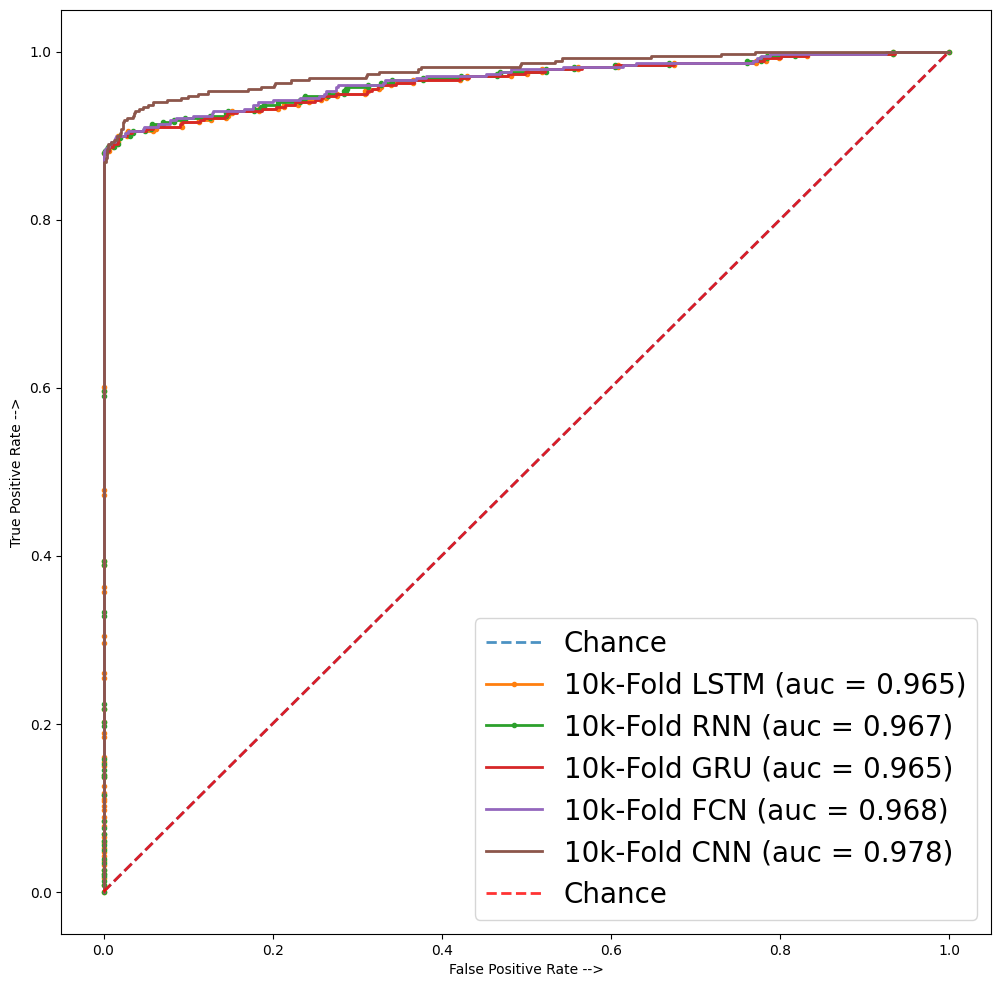

In [ ]:
# replace X1 with X_test and Y1 with y_test
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt



plt.figure(figsize=(12, 12))  # Adjust figure size and dpi as needed
plt.plot([0, 1], [0, 1], linestyle="--", lw=2,  label="Chance", alpha=0.8)
plt.plot(lstm_fpr, lstm_tpr,lw=2, marker='.', label='10k-Fold LSTM (auc = %0.3f)' % lstm_roc_auc)
plt.plot(rnn_fpr, rnn_tpr,lw=2, marker='.', label='10k-Fold RNN (auc = %0.3f)' % rnn_roc_auc)
plt.plot(gru_fpr, gru_tpr,lw=2,linestyle='-', label='10k-Fold GRU (auc = %0.3f)' % gru_roc_auc)
plt.plot(fcn_fpr, fcn_tpr,lw=2, linestyle='-', label='10k-Fold FCN (auc = %0.3f)' % fcn_roc_auc)
plt.plot(cnn_fpr, cnn_tpr,lw=2, linestyle='-', label='10k-Fold CNN (auc = %0.3f)' % cnn_roc_auc)

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')

# plt.xlabel('False Positive Rate -->')
# plt.ylabel('True Positive Rate -->')

plt.legend(loc="lower right", fontsize=20, ncol=1)

plt.show()

<ipython-input-1-87e1e0d6457c>:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=ax, y=v10["Accuracy"], x=v10["folds"], palette=palette)


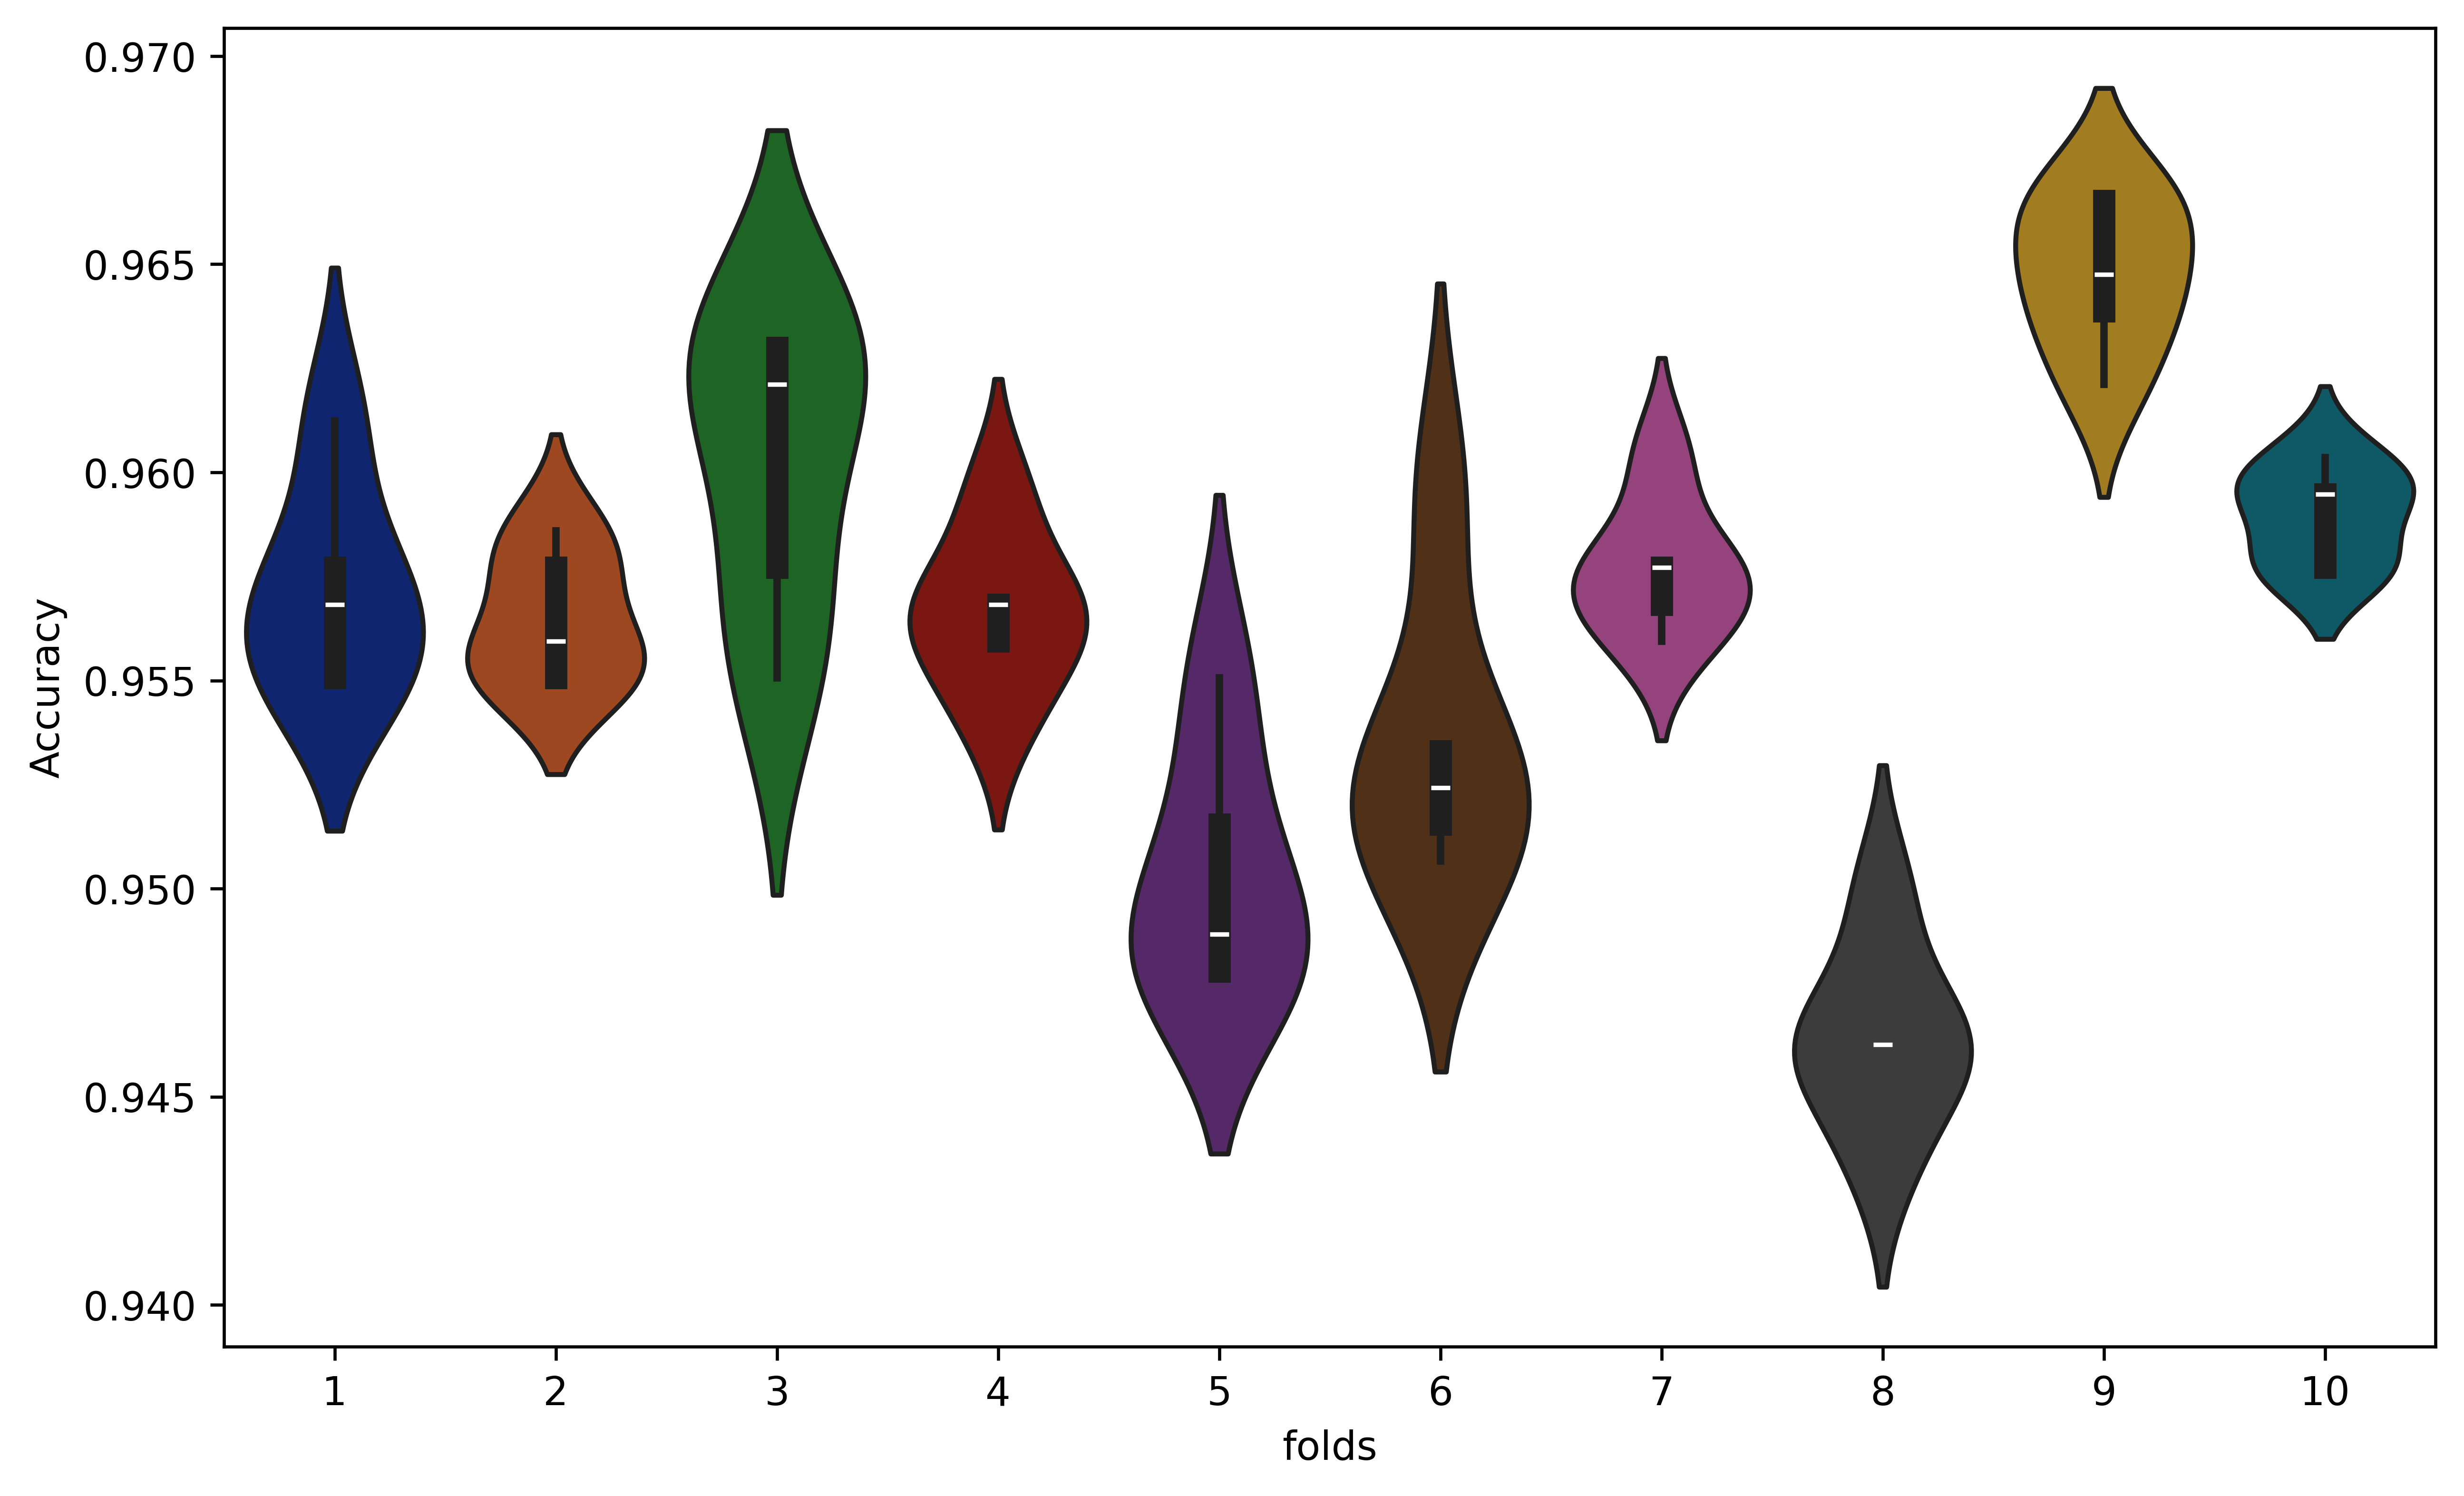

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Defining accuracy data for different models across 10 folds
LSTM = {'Accuracy':[0.9550660848617554, 0.9559471607208252, 0.9550660848617554,
    0.9568281769752502, 0.9480175971984863, 0.9533039927482605,
    0.9577092528343201, 0.9462555050849915, 0.966519832611084,
    0.9577092528343201],
    'folds': [1,2,3,4,5,6,7,8,9,10],
    'algo': 'LSTM'}
LSTM = pd.DataFrame(LSTM)

SimpleRNN = {'Accuracy':[0.9550660848617554, 0.9550660848617554, 0.9629955887794495, 0.9541850090026855,
                   0.9488986730575562, 0.950660765171051, 0.9559471607208252, 0.9436123371124268,
                   0.9647576808929443, 0.9577092528343201],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'SimpleRNN'}
SimpleRNN = pd.DataFrame(SimpleRNN)

GRU = {'Accuracy':[0.9568281938325991, 0.9550660792951542, 0.9577092511013215, 0.9568281938325991,
                   0.9480176211453745, 0.9515418502202643, 0.9577092511013215,
                   0.9462555066079296, 0.9621145374449339, 0.9594713656387666],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'GRU'}
GRU = pd.DataFrame(GRU)

FCN = {'Accuracy':[0.9577092511013215, 0.9577092511013215, 0.9629955947136564,
                   0.9594713656387666, 0.9515418502202643, 0.9524229074889868,
                   0.960352422907489, 0.9497797356828194, 0.9665198237885463, 0.960352422907489],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'FCN'}
FCN = pd.DataFrame(FCN)

CNN = {'Accuracy':[0.9612334801762115, 0.958590308370044, 0.9621145374449339,
                   0.9559471365638766, 0.9550660792951542, 0.9594713656387666,
                   0.9568281938325991, 0.9462555066079296, 0.9638766519823788,
                   0.9594713656387666],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'CNN'}
CNN = pd.DataFrame(CNN)

# Combine all dataframes
v10 = pd.concat([LSTM, SimpleRNN, GRU, FCN, CNN], axis=0)

from matplotlib import pyplot as plt
import seaborn as sns

# Define figure dimensions and other plot settings
a4_dims = (10, 6)
fig, ax = plt.subplots(figsize=a4_dims, dpi=600)

# Choose a color palette (examples: 'Set1', 'Set2', 'Spectral', 'coolwarm', etc.)
palette = "dark"  # Or specify your custom list of colors

# Plot with Seaborn using the chosen palette
sns.violinplot(ax=ax, y=v10["Accuracy"], x=v10["folds"], palette=palette)

# Display the plot
plt.show()




<ipython-input-5-2d7b6cd2bbf8>:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='algo', y='Accuracy', data=df, palette=custom_palette, width=0.2, order=order)


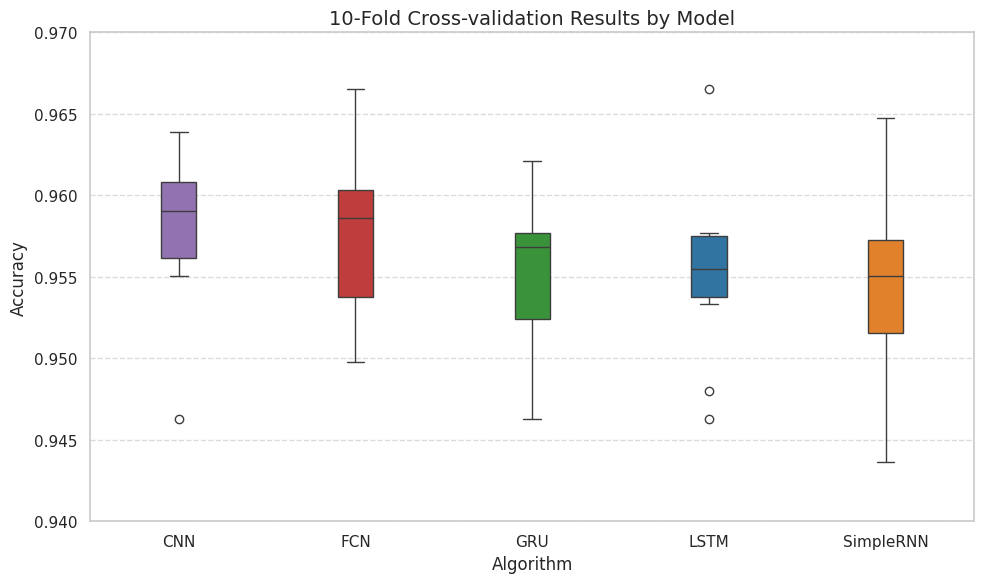

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Defining accuracy data for different models across 10 folds
LSTM = {'Accuracy':[0.9550660848617554, 0.9559471607208252, 0.9550660848617554,
    0.9568281769752502, 0.9480175971984863, 0.9533039927482605,
    0.9577092528343201, 0.9462555050849915, 0.966519832611084,
    0.9577092528343201],
    'folds': [1,2,3,4,5,6,7,8,9,10],
    'algo': 'LSTM'}
LSTM = pd.DataFrame(LSTM)

SimpleRNN = {'Accuracy':[0.9550660848617554, 0.9550660848617554, 0.9629955887794495, 0.9541850090026855,
                   0.9488986730575562, 0.950660765171051, 0.9559471607208252, 0.9436123371124268,
                   0.9647576808929443, 0.9577092528343201],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'SimpleRNN'}
SimpleRNN = pd.DataFrame(SimpleRNN)

GRU = {'Accuracy':[0.9568281938325991, 0.9550660792951542, 0.9577092511013215, 0.9568281938325991,
                   0.9480176211453745, 0.9515418502202643, 0.9577092511013215,
                   0.9462555066079296, 0.9621145374449339, 0.9594713656387666],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'GRU'}
GRU = pd.DataFrame(GRU)

FCN = {'Accuracy':[0.9577092511013215, 0.9577092511013215, 0.9629955947136564,
                   0.9594713656387666, 0.9515418502202643, 0.9524229074889868,
                   0.960352422907489, 0.9497797356828194, 0.9665198237885463, 0.960352422907489],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'FCN'}
FCN = pd.DataFrame(FCN)

CNN = {'Accuracy':[0.9612334801762115, 0.958590308370044, 0.9621145374449339,
                   0.9559471365638766, 0.9550660792951542, 0.9594713656387666,
                   0.9568281938325991, 0.9462555066079296, 0.9638766519823788,
                   0.9594713656387666],
        'folds': [1,2,3,4,5,6,7,8,9,10],
      'algo': 'CNN'}
CNN = pd.DataFrame(CNN)

# Combine all model DataFrames
df = pd.concat([LSTM, SimpleRNN, GRU, FCN, CNN], axis=0)

# Set the plot style
sns.set(style="whitegrid")

# Define custom color palette
custom_palette = {
    'LSTM': '#1f77b4',       # Blue
    'SimpleRNN': '#ff7f0e',  # Orange
    'GRU': '#2ca02c',        # Green
    'FCN': '#d62728',        # Red
    'CNN': '#9467bd'         # Purple
}

# Order algorithms by median accuracy
order = df.groupby('algo')['Accuracy'].median().sort_values(ascending=False).index.tolist()

# Create box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='algo', y='Accuracy', data=df, palette=custom_palette, width=0.2, order=order)

# Labels and title
plt.title('10-Fold Cross-validation Results by Model', fontsize=14)
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Optional: limit y-axis if values are very close (zoom effect)
plt.ylim(0.94, 0.97)

# Y-axis grid only
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()